1. **Importing** **Dependencies**




In [ ]:

import pandas as pd #pd.read_csv , df.info , df.desc , df.head.....
import os  #Imported this to use list directory function (os.listdir(path)) || to check the file name in the system
import kagglehub #Imported this to use the dataset without installing it to pc
import matplotlib.pyplot as plt #for simple graphs
import seaborn as sns #for heatmap, confusion matrix, histogram
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix ,classification_report,roc_auc_score,roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



2. **Importing Data from Kaggle and Understanding Data**

In [ ]:


path = kagglehub.dataset_download("blastchar/telco-customer-churn")
#to use dataset without downloading it to pc

print(os.listdir(path)) #to see file name.

df = pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
#specifying that data frame (table) should be taken from this csv file.

df.drop(['customerID'],axis= 1, inplace= True)   #delete customer id because it doesn't help in predicting anything.

100%|██████████| 172k/172k [00:00<00:00, 44.9MB/s]

Extracting files...
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
df.info() #describe the table to see how many values are categorical. (non-numeric)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
# printing unique values of catogorical columns to understand the data and figure out which encoding we will use.

numerical_columns = ['tenure','MonthlyCharges','TotalCharges']

for col in df.columns: #for all the columns in our table, select only the ones not in the numerical columns array.
  if col not in numerical_columns:
    print(f"{col} has {df[col].unique()} unique values") #print the values which are unique. If we remove .unique() it prints first and last 5 values.
    print("-"*40)  # just to add a line between the output rows.

gender has ['Female' 'Male'] unique values
----------------------------------------
SeniorCitizen has [0 1] unique values
----------------------------------------
Partner has ['Yes' 'No'] unique values
----------------------------------------
Dependents has ['No' 'Yes'] unique values
----------------------------------------
PhoneService has ['No' 'Yes'] unique values
----------------------------------------
MultipleLines has ['No phone service' 'No' 'Yes'] unique values
----------------------------------------
InternetService has ['DSL' 'Fiber optic' 'No'] unique values
----------------------------------------
OnlineSecurity has ['No' 'Yes' 'No internet service'] unique values
----------------------------------------
OnlineBackup has ['Yes' 'No' 'No internet service'] unique values
----------------------------------------
DeviceProtection has ['No' 'Yes' 'No internet service'] unique values
----------------------------------------
TechSupport has ['No' 'Yes' 'No internet service'] uniq

**3. Dealing with Missing values**

In [ ]:
#to check how many entries are missing
for col in df.columns:
    if df[col].dtype == "object": #if column has text values then
        blanks = (df[col].str.strip() == "").sum() #In Python, .strip() removes whitespaces from the beginning and ending of strings. so .str allows the given python function to be applied to all strings in  a column.
    else:      # =="" checks empty strings
        blanks = df[col].isna().sum()  #.isna() checks missing values.
    if blanks > 0:
        print(f"{col} has {blanks} missing values (NaN or blanks)")

TotalCharges has 11 missing values (NaN or blanks)


In [ ]:
df[df["TotalCharges"]==" "]   #print all columns with total charges missing

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
df["TotalCharges"]=df["TotalCharges"].replace(" ","0")   #tenure is 0, no billing cycle has been completed yet.

df["TotalCharges"]=df["TotalCharges"].astype(float)      #We replaced these values with 0 instead of statistical values because

**EDA**       

In [ ]:
df.describe() #This is only displaying four columns because it works on Numerical data alone.

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


The typical customer pays about 65 per month, though prices vary quite a bit. The dataset includes both brand-new and long-term customers, with most customers not being senior citizens (only about 16% are). Total lifetime spending varies widely, with some customers spending much more than others, suggesting possible outliers or long-tenure users.

In [ ]:
# plot histogram (function definition)
def plot_hist(df,col_name):

    plt.figure(figsize=(4,3))
    sns.histplot(df[col_name],kde=True)  #creating a coloured curve (pdf)
    plt.title(f"Distribution of {col_name}")

    col_mean=df[col_name].mean()
    col_median=df[col_name].median()

    plt.axvline(col_mean,color="red",linestyle="--",label=f"Mean: {col_mean:.2f}")
    plt.axvline(col_median,color="blue",linestyle="--",label=f"Median: {col_median:.2f}")

    plt.legend()
    plt.show()

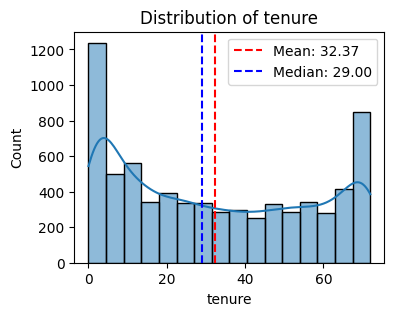

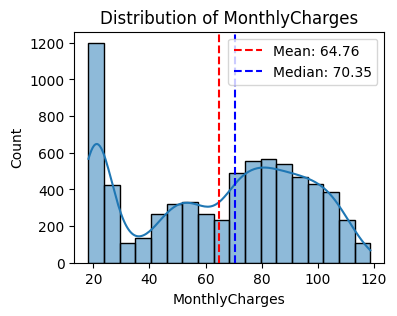

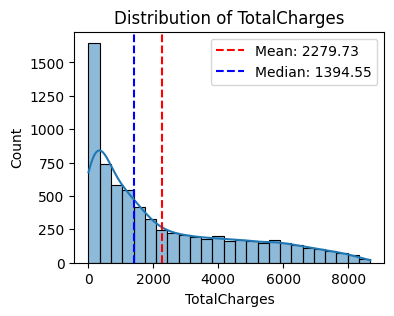

In [ ]:
# plot histograms for all numerical columns
for col in numerical_columns:
    plot_hist(df,col)

In [ ]:
print(df['Churn'].value_counts(normalize=True)*100) #To check class imbalance. (We will deal with class imbalance after we split the data for training and testing.)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].median()
# Customers who churn have lower tenure,and higher monthly charges and total charges than those who don't.

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1679.525
Yes,10.0,79.650,703.550


In [ ]:
catagorical_columns=[col for col in df.columns if col not in numerical_columns and col!="Churn"]

**Encoding:**

In [ ]:
#we convert to 0 and 1

cols = ['Partner', 'PhoneService', 'PaperlessBilling','Dependents']
for col in cols:
    df[col] = (df[col] == 'Yes').astype(int)  #checks if value equals Yes. If it is equal, it returns bool true which is written as 1 due to the .astype(int)

  # gender: Female=1, Male=0

    df['gender'] = (df['gender'] == 'Female').astype(int)

In [ ]:
#0/1 mapping
internet_related = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies']

for col in internet_related:
     df[col] = df[col].map({'No':0,'Yes':1})
     df[col] = df[col].fillna(0).astype(int) #"No service" encoded as 0

df['MultipleLines'] = df['MultipleLines'].map({'No':0,'Yes':1})
df['MultipleLines'] = df['MultipleLines'].fillna(0).astype(int)

In [ ]:
#0/1 mapping of Churn column
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

In [ ]:
binary_cols = [
    'Partner','PhoneService','PaperlessBilling',
    'Dependents','MultipleLines',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies',
    'gender'
]

nominal_cols = ['InternetService','PaymentMethod']

ordinal_cols = ['Contract']



In [ ]:
df["num_services"] = df[internet_related].sum(axis=1)


In [ ]:

df.drop(columns=internet_related,inplace=True)
df.drop(columns=['gender','Partner'], inplace=True)
df.head()

,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_services
0,0,0,1,0,0,DSL,Month-to-month,1,Electronic check,29.85,29.85,0,1
1,0,0,34,1,0,DSL,One year,0,Mailed check,56.95,1889.50,0,2
2,0,0,2,1,0,DSL,Month-to-month,1,Mailed check,53.85,108.15,1,2
3,0,0,45,0,0,DSL,One year,0,Bank transfer (automatic),42.30,1840.75,0,3
4,0,0,2,1,0,Fiber optic,Month-to-month,1,Electronic check,70.70,151.65,1,0


In [ ]:
df.shape

(7043, 13)

Splitting:

In [ ]:
X=df.drop("Churn",axis=1) #We don't keep target in the training set that's why we have to drop Churn.
y=df["Churn"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)  #splitting of data

Preprocessing

In [ ]:
# we will use different preprocessing for tree based models and logistic regression
# because tree based models are not affected by feature scaling and can handle ordinal features without encoding,
# while logistic regression is sensitive to feature scales and requires all features to be numeric.

preprocessor_logistic = ColumnTransformer(
    transformers=[

        ('nominal', OneHotEncoder(drop='first',handle_unknown='ignore'), nominal_cols),
        ('ordinal', OrdinalEncoder(categories=[['Month-to-month','One year','Two year']]), ordinal_cols),
        ('numerical', StandardScaler(), numerical_columns)

    ],remainder='passthrough'
)

In [ ]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(drop='first',handle_unknown='ignore'), nominal_cols),
        ('ordinal', OrdinalEncoder(categories=[['Month-to-month','One year','Two year']]), ordinal_cols),
        ('numerical', 'passthrough', numerical_columns)

    ],remainder='passthrough'
)

***Model Training***

In [ ]:
logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_logistic),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
)
#balance handles class imbalance,gives priority to miniority

In [ ]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_tree),
       ('classifier', RandomForestClassifier(n_estimators=300,max_depth=4,min_samples_split=12,
        min_samples_leaf=3,max_features='sqrt',random_state=42, class_weight='balanced_subsample'))
    ]
)

In [ ]:
numerical_columns += ["num_services"]

In [ ]:
logistic_model.fit(X_train, y_train) #training

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['InternetService',
                                                   'PaymentMethod']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'num_services'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
rf_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['InternetService',
                                                   'PaymentMethod']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('numerical', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'num_services'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=4, min_samples_leaf=3,
                                        min_samples_split=12, n_estimators=300,
                                        random_state=42))])

In [ ]:
log_prob = logistic_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]


In [ ]:

log_pred=(log_prob >= 0.42).astype(int)
rf_pred=(rf_prob >= 0.4).astype(int)


In [ ]:
print("Logistic")
print(classification_report(y_test, log_pred))
print("Roc AUC:", roc_auc_score(y_test, log_prob))

print("Random Forest")
print(classification_report(y_test, rf_pred))
print("Roc AUC:", roc_auc_score(y_test, rf_prob))



Logistic
              precision    recall  f1-score   support

           0       0.94      0.65      0.77      1036
           1       0.47      0.88      0.62       373

    accuracy                           0.71      1409
   macro avg       0.71      0.76      0.69      1409
weighted avg       0.82      0.71      0.73      1409

Roc AUC: 0.864326601592017
Random Forest
              precision    recall  f1-score   support

           0       0.95      0.59      0.73      1036
           1       0.45      0.92      0.60       373

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.82      0.68      0.69      1409

Roc AUC: 0.863731406626849


In [ ]:
def plot_confusion(y_true, y_prob, threshold, model_name, ax):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name}")


In [ ]:
def plot_roc_curve(y_true, y_prob, model_name, ax):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, label=f"AUC={auc_score:.3f}")
    ax.plot([0,1], [0,1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name}")
    ax.legend()


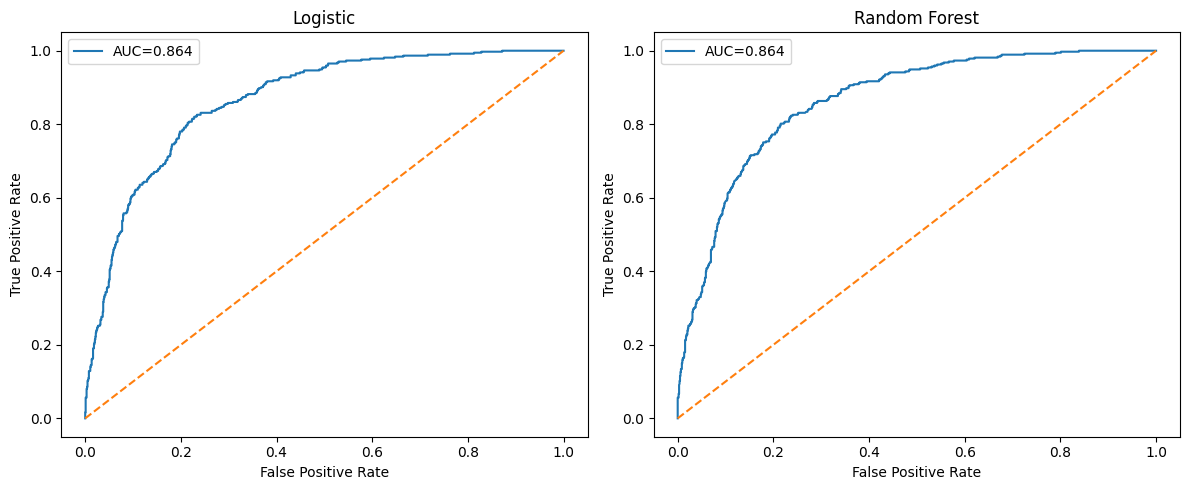

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_roc_curve(y_test, log_prob, "Logistic", axes[0])
plot_roc_curve(y_test, rf_prob, "Random Forest", axes[1])


plt.tight_layout()
plt.show()


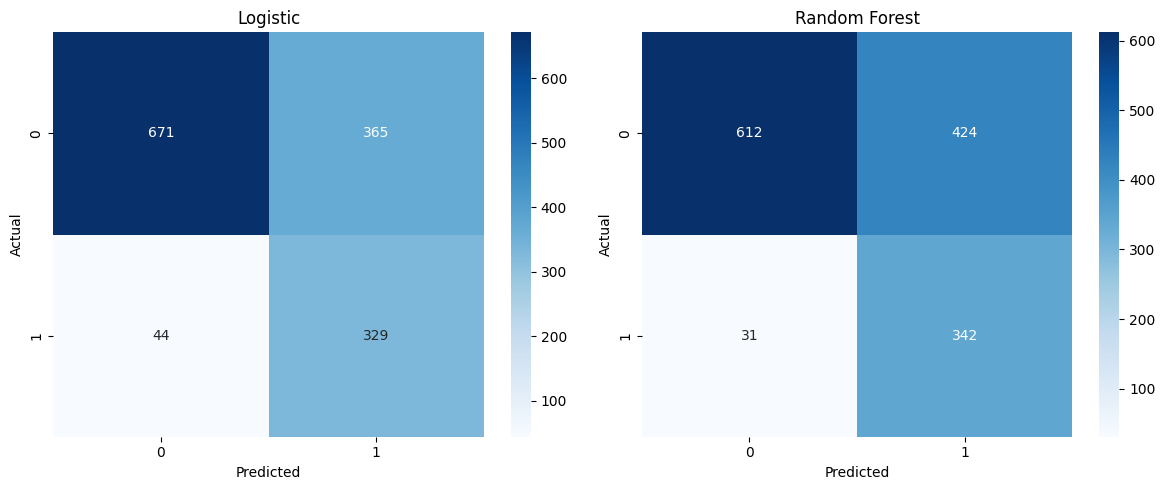

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_confusion(y_test, log_pred, 0.42, "Logistic", axes[0])
plot_confusion(y_test, rf_pred, 0.4, "Random Forest", axes[1])


plt.tight_layout()
plt.show()


Names used through the code:
numerical_columns = ['tenure','MonthlyCharges','TotalCharges']

internet_related = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies']

    
  binary_cols = [
    'Partner','PhoneService','PaperlessBilling',
    'Dependents','MultipleLines',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies',
    'gender'
]

nominal_cols = ['InternetService','PaymentMethod']

ordinal_cols = ['Contract']


numerical_columns = ['tenure','MonthlyCharges','TotalCharges']


tenure outliers: 0


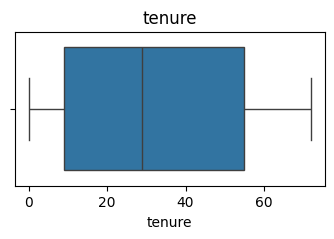

MonthlyCharges outliers: 0


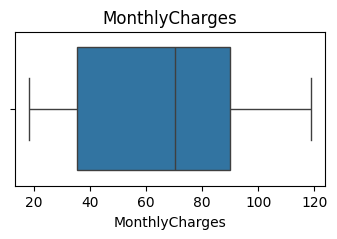

TotalCharges outliers: 0


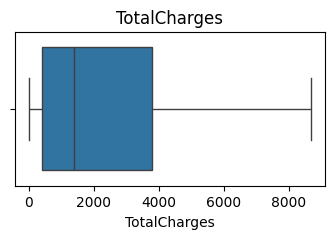

num_services outliers: 0


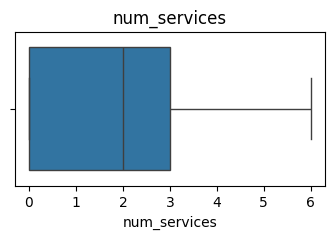

In [ ]:
def check_outliers(df,col):    #create a function with parameter dataframe and col
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    print(col, "outliers:",
          ((df[col] < lower) | (df[col] > upper)).sum())
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
for col in numerical_columns:
   check_outliers(df,col)